### 一个简单的例子

In [53]:
import torch

x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [54]:
x.requires_grad_(True) #等价于x=torch.arange(4.0,requires_grad=True)
print(x.grad) #默认值是none

None


In [55]:
y = 2 * torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [56]:
y.backward()
x.grad


tensor([ 0.,  4.,  8., 12.])

In [57]:
# 在默认情况下，PyTorch会累积梯度，我们需要清除之前的值
x.grad.zero_()
y = x.sum()
y.backward()
x.grad


tensor([1., 1., 1., 1.])

### 非标量变量的反向传播

In [58]:
# 对非标量调用backward需要传入一个gradient参数，该参数指定微分函数关于self的梯度。
# 本例只想求偏导数的和，所以传递一个1的梯度是合适的
x.grad.zero_()
y = x * x
# 等价于y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

### 分离计算

In [59]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x

z.sum().backward()
x.grad == u


tensor([True, True, True, True])

In [60]:
x.grad.zero_()
y.sum().backward()
x.grad == 2 * x

tensor([True, True, True, True])

### Python控制流的梯度计算

In [70]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

a = torch.randn(size=(3,4), requires_grad=True) #size=()表示0维张量，即标量
d = f(a)
d.sum().backward()
a.grad == d / a
torch.allclose(a.grad, d/a)

True

### 练习


In [ ]:
#1第二次反向传播需要保留第一次的计算图（默认情况下 backward 之后计算图会被销毁），
#所以需要额外内存和计算
y.sum().backward(create_graph=True)  # 保留计算图
x.grad.backward()              # 再反向一次得到二阶导


In [ ]:
#2 反向传播之后立即再次运行会发生什么？
#报错。
#因为 PyTorch 默认在 .backward() 之后自动销毁计算图（为了节省内存）。
#再次调用 .backward() 时计算图已经不存在了

#如果需要多次反向传播，要在第一次调用时加 retain_graph=True:
y.backward(retain_graph=True)  # 保留计算图
y.backward()                   # 可以再次反向

In [ ]:
#4
def g(x):
    b = None
    if x.norm() > 10:
        b = x.sum()
    else:
        b = (x ** 2).sum()
    return b

x = torch.arange(10.0, requires_grad=True)
y = g(x)
y.backward()
x.grad

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [86]:
#5
x = torch.arange(0, 2 * torch.pi, 0.1, requires_grad=True)
y = torch.sin(x)
y.sum().backward()

In [85]:
#from matplotlib_inline import backend_inline
from d2l import torch as d2l


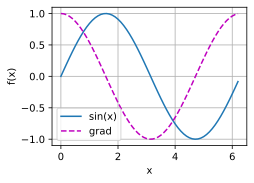

In [89]:
plot(x.detach(), [y.detach(), x.grad], 'x', 'f(x)', legend=['sin(x)', 'grad'])

In [97]:
x = torch.tensor ([2.0], requires_grad=True)
y = x ** 3 - 2 * x **2 + x
y.backward()
torch.allclose(x.grad, torch.tensor([5.0]))


True

In [102]:
x = torch.arange(4.0, requires_grad=True)
y = x * x
y.sum().backward()
print(x.grad)

# 第二次
x.grad.zero_()
y = x * x
y.sum().backward()
print(x.grad)

tensor([0., 2., 4., 6.])
tensor([0., 2., 4., 6.])
